# This is a review of the EM algorithm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

In [ ]:
def gaussian_density(x:np.ndarray, m:float, sigma:float):
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-(x-m)**2/(2*sigma**2))

In [ ]:
class GaussianMixture1D():
    def __init__(self, J:int):
        self.J = J
        self.alphas = np.ones(J)/J
        self.means = np.random.uniform(-J, J, J) # Random means
        self.sigmas = np.random.uniform(.2, .5, J) # np.random.chisquare(2, J)/(J*2) # Random sigmas

    def density(self, x:np.ndarray):
        f = np.zeros_like(x)
        for j in range(self.J):
            f += self.alphas[j]*gaussian_density(x, self.means[j], self.sigmas[j])
        return f
    
    def log_likelihood(self, x:np.ndarray):
        return sum(self.density(x))

    def plot_density(self, X_samples=None):
        plt.clf()
        max_samples = np.max(np.abs(X_samples)) if X_samples is not None else 0
        bound = max(np.max(np.abs(self.means)), max_samples) + 1
        X = np.linspace(-bound, bound, 1000)
        if X_samples is not None:
            plt.hist(X_samples, 50, density=True, color='orange')
        plt.plot(X, self.density(X), color='b')
        plt.show()

    def plot_density_against_other(self, other):
        plt.clf()
        bound = np.max(np.abs(self.means)) + 2
        X = np.linspace(-bound, bound, 1000)
        plt.plot(X, self.density(X), color='b', label="Ground Truth")
        plt.plot(X, other.density(X), color='orange', label="Approx")
        plt.legend()
        plt.show()
        
    def sample(self, n:int): # n be the number of samples
        Z = np.random.randint(self.J, size=(n,))
        # Counts the number of occurences of each number
        numbers, counts = np.unique(Z, return_counts=True) 
        samples = list()
        for j, count in zip(numbers, counts):
            # sample independantly counts[j] samples from a normal or parameters j
            sample=np.random.normal(self.means[j], self.sigmas[j], count)
            samples.append(sample)
        
        # Shuffle them for randomness
        samples = np.concatenate(samples)
        np.random.shuffle(samples)
        return samples

In [ ]:
J = 4
n_sample = 100

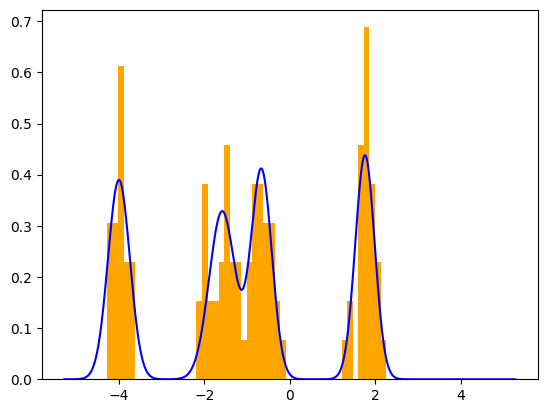

In [ ]:
gaussian_mixture = GaussianMixture1D(J)
X_samples = gaussian_mixture.sample(n_sample)
gaussian_mixture.plot_density(X_samples)

In [ ]:
print(gaussian_mixture.log_likelihood(X_samples))

29.676979473943568


# EM algorithm

$$
H^{(k)}_{i,j} = \frac{\alpha_k(j) \gamma_{m_k(j), v_k(j)}(\mathbf{X}_i)}{\sum_{l=1}^J \alpha_k(l) \gamma_{m_k(l), v_k(l)}(\mathbf{X}_i)}
$$

Puis
$$
\alpha_{1}(j) = \frac{1}{n}\sum_{i=1}^n H^{(k)}_{i,j}
$$
$$
m_{1}(j) = \frac{\sum_{i=1}^n\mathbf{X}_i H^{(k)}_{i,j}}{\sum_{i=1}^n H^{(1)}_{i,j}}
$$
$$
v_1(j)=\frac{\sum_{i=1}^n\left(\mathbf{X}_i - m_j\right)^2 H^{(k)}_{i,j}}{\sum_{i=1}^n H^{(k)}_{i,j}}
$$

In [ ]:
def H(alpha_k, m_k, v_k):
    H = np.empty((n_sample, J))
    for i in range(n_sample):
        denominator = sum([alpha_k[l]*gaussian_density(X_samples[i], m_k[l], np.sqrt(v_k[l])) for l in range(J)])
        for j in range(J):
            H[i,j] = alpha_k[j]*gaussian_density(X_samples[i], m_k[j], np.sqrt(v_k[j]))/denominator
    return H

In [ ]:
def alpha(j, H_k):
    return np.mean(H_k[:, j], axis=0)

def m(j, H_k):
    return np.sum(X_samples*H_k[:,j])/np.sum(H_k[:,j])

def v(j, H_k, m_k):
    return np.sum((X_samples-m_k[j])**2 * H_k[:,j])/np.sum(H_k[:,j])

In [ ]:
epochs = 150
print_every = 50

In [ ]:
# Initial state
alpha_k = np.ones(J)/J
m_k = (np.arange(J) - (J-1)/2) /20 # np.zeros(J)
v_k = np.ones(J)

approx_mixture = GaussianMixture1D(J)
approx_mixture.alphas = alpha_k
approx_mixture.means = m_k
approx_mixture.sigmas = np.sqrt(v_k)

# approx_mixture.plot_density()

In [ ]:
def update_params(alpha_k, m_k, v_k):
    H_k = H(alpha_k, m_k, v_k)
    alpha_new = np.array([alpha(j, H_k) for j in range(J)])
    m_new = np.array([m(j, H_k) for j in range(J)])
    v_new = np.array([v(j, H_k, m_k) for j in range(J)])
    return alpha_new, m_new, v_new

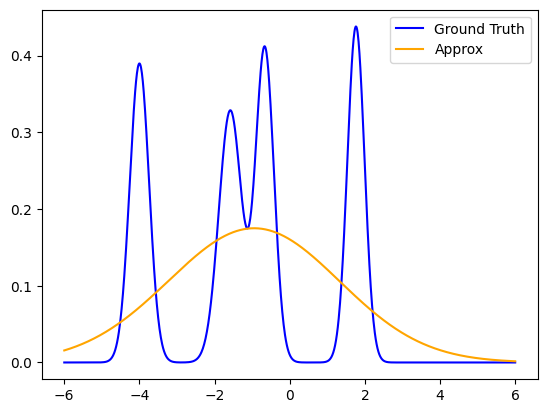

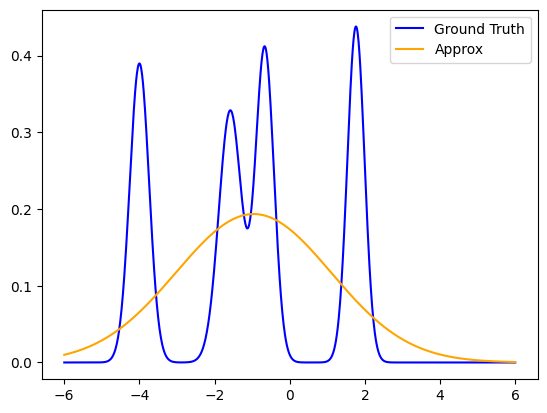

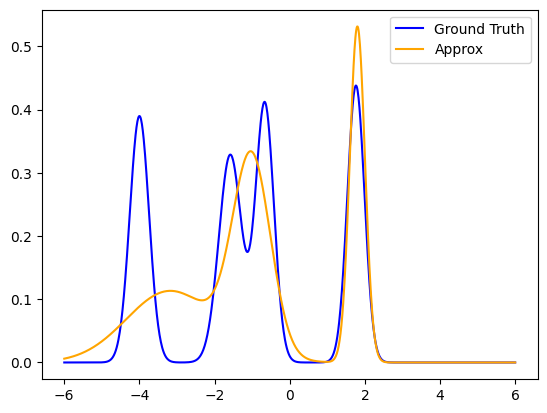

In [ ]:
log_likelihood_per_epochs = []

for epoch in range(epochs):
    alpha_k, m_k, v_k = update_params(alpha_k, m_k, v_k)
    
    approx_mixture.alphas = alpha_k
    approx_mixture.means = m_k
    approx_mixture.sigmas = np.sqrt(v_k)
    log_likelihood_per_epochs.append(approx_mixture.log_likelihood(X_samples))
    if epoch % print_every == 0:
        gaussian_mixture.plot_density_against_other(approx_mixture)
 

30.790865775057544


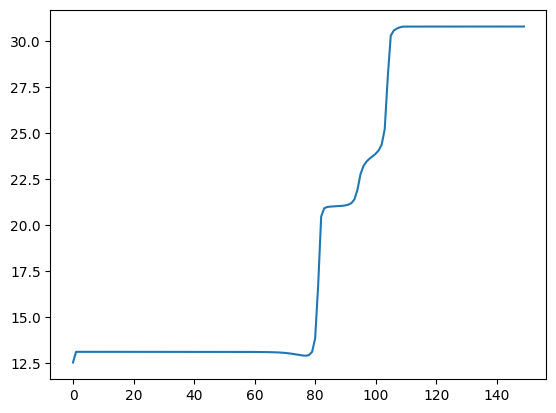

In [ ]:
plt.clf()
plt.plot(log_likelihood_per_epochs)
print(log_likelihood_per_epochs[-1])

## Cas d'une initialisation dégénérée

Si on commence avec $\forall j, \alpha_0(j)=\frac{1}{J}, m_0(j)=m, v_0(j)=v$, alors,
$$
H^{(0)}_{i,j} = \frac{\alpha_0(j) \gamma_{m_0(j), v_0(j)}(\mathbf{X}_i)}{\sum_{l=1}^J \alpha_0(l) \gamma_{m_0(l), v_0(l)}(\mathbf{X}_i)}
= \frac{\frac{1}{J} \gamma_{m, v}(\mathbf{X}_i)}{J \times \frac{1}{J} \gamma_{m, v}(\mathbf{X}_i)}
= \frac{1}{J}
$$

Puis
$$
\alpha_{1}(j) = \frac{1}{n}\sum_{i=1}^n H^{(0)}_{i,j} = \frac{1}{J}
$$
$$
m_{1}(j) = \frac{\sum_{i=1}^n\mathbf{X}_i H^{(0)}_{i,j}}{\sum_{i=1}^n H^{(1)}_{i,j}} = \frac{1}{n}\sum_{i=1}^n\mathbf{X}_i = \bar{\mathbf{X}}
$$
$$
v_1(j)=\frac{\sum_{i=1}^n\left(\mathbf{X}_i - m_j\right)^2 H^{(0)}_{i,j}}{\sum_{i=1}^n H^{(0)}_{i,j}} = \frac{\sum_{i=1}^n\left(\mathbf{X}_i - \bar{\mathbf{X}}\right)^2 \frac{1}{J}}{n \frac{1}{J}} = \frac{1}{n} \sum_{i=1}^n\left(\mathbf{X}_i - \bar{\mathbf{X}}\right)^2 = \hat{\sigma_n^2}
$$

En continuant par récurrence, $\forall k>1$ :
$$
H^{(k)}_{i,j}
= \frac{\frac{1}{J} \gamma_{\bar{\mathbf{X}}, \hat{\sigma_n^2}}(\mathbf{X}_i)}{J \times \frac{1}{J} \gamma_{\bar{\mathbf{X}}, \hat{\sigma_n^2}}(\mathbf{X}_i)}
= \frac{1}{J}
$$
$$
\alpha_{k}(j) = \frac{1}{n}\sum_{i=1}^n H^{(0)}_{i,j} = \frac{1}{J}
$$
$$
m_{k}(j) = \frac{1}{n}\sum_{i=1}^n\mathbf{X}_i = \bar{\mathbf{X}}
$$
$$
v_k(j) = \frac{\sum_{i=1}^n\left(\mathbf{X}_i - \bar{\mathbf{X}}\right)^2 \frac{1}{J}}{n \frac{1}{J}} = \frac{1}{n} \sum_{i=1}^n\left(\mathbf{X}_i - \bar{\mathbf{X}}\right)^2 = \hat{\sigma_n^2}
$$

Donc une initialisation avec toutes les mêmes valeurs donne en tout temps une Gaussienne comme approximation : Il faut préférer une initialisation plus étendue.